### Load features

In [16]:
from pathlib import Path
import pandas as pd

# ============================================================
# PROJECT ROOT
# ============================================================

PROJECT_ROOT = Path(
    r"C:\Users\DIPANSHU SHUKLA\OneDrive\Desktop\SIH_162_ML"
)

print("PROJECT ROOT:")
print(PROJECT_ROOT)

# ============================================================
# FEATURE FILE
# ============================================================

FEATURE_FILE = (
    PROJECT_ROOT
    / "data"
    / "features"
    / "thermal_features_prototype.csv"
)

print("\nFEATURE FILE:")
print(FEATURE_FILE)

print("\nFile exists:", FEATURE_FILE.exists())

PROJECT ROOT:
C:\Users\DIPANSHU SHUKLA\OneDrive\Desktop\SIH_162_ML

FEATURE FILE:
C:\Users\DIPANSHU SHUKLA\OneDrive\Desktop\SIH_162_ML\data\features\thermal_features_prototype.csv

File exists: True


In [17]:
data = pd.read_csv(FEATURE_FILE)

print("Shape:", data.shape)

data.head()

Shape: (439251, 22)


,acq_date,start_time,end_time,latitude,longitude,observation_count,duration_minutes,mean_frp,peak_frp,total_frp,...,frp_per_observation,mean_brightness,start_hour,day_of_week,month,is_weekend,persistent,long_duration,is_day,is_night
0,2025-01-01,2025-01-01 08:01:00,2025-01-01 08:01:00,8.984920,77.60124,1,0.0,8.350,8.35,8.35,...,8.350,341.700,8,2,1,0,0,0,1,0
1,2025-01-01,2025-01-01 08:01:00,2025-01-01 08:01:00,9.000140,77.61005,1,0.0,2.680,2.68,2.68,...,2.680,330.680,8,2,1,0,0,0,1,0
2,2025-01-01,2025-01-01 08:01:00,2025-01-01 08:01:00,9.278090,78.04165,1,0.0,1.580,1.58,1.58,...,1.580,330.240,8,2,1,0,0,0,1,0
3,2025-01-01,2025-01-01 19:49:00,2025-01-01 19:49:00,9.562105,77.63444,2,0.0,1.105,1.23,2.21,...,1.105,303.515,19,2,1,0,1,0,0,1
4,2025-01-01,2025-01-01 07:38:00,2025-01-01 07:38:00,9.630170,76.47209,1,0.0,2.110,2.11,2.11,...,2.110,335.260,7,2,1,0,0,0,1,0


In [18]:
import pandas as pd
import numpy as np

data = pd.read_csv(FEATURE_FILE)

print("Shape:", data.shape)
print("\nColumns:")
print(data.columns.tolist())

data.head()

Shape: (439251, 22)

Columns:
['acq_date', 'start_time', 'end_time', 'latitude', 'longitude', 'observation_count', 'duration_minutes', 'mean_frp', 'peak_frp', 'total_frp', 'frp_range', 'frp_peak_ratio', 'frp_per_observation', 'mean_brightness', 'start_hour', 'day_of_week', 'month', 'is_weekend', 'persistent', 'long_duration', 'is_day', 'is_night']


,acq_date,start_time,end_time,latitude,longitude,observation_count,duration_minutes,mean_frp,peak_frp,total_frp,...,frp_per_observation,mean_brightness,start_hour,day_of_week,month,is_weekend,persistent,long_duration,is_day,is_night
0,2025-01-01,2025-01-01 08:01:00,2025-01-01 08:01:00,8.984920,77.60124,1,0.0,8.350,8.35,8.35,...,8.350,341.700,8,2,1,0,0,0,1,0
1,2025-01-01,2025-01-01 08:01:00,2025-01-01 08:01:00,9.000140,77.61005,1,0.0,2.680,2.68,2.68,...,2.680,330.680,8,2,1,0,0,0,1,0
2,2025-01-01,2025-01-01 08:01:00,2025-01-01 08:01:00,9.278090,78.04165,1,0.0,1.580,1.58,1.58,...,1.580,330.240,8,2,1,0,0,0,1,0
3,2025-01-01,2025-01-01 19:49:00,2025-01-01 19:49:00,9.562105,77.63444,2,0.0,1.105,1.23,2.21,...,1.105,303.515,19,2,1,0,1,0,0,1
4,2025-01-01,2025-01-01 07:38:00,2025-01-01 07:38:00,9.630170,76.47209,1,0.0,2.110,2.11,2.11,...,2.110,335.260,7,2,1,0,0,0,1,0


Select ML features

In [19]:
feature_columns = [
    "observation_count",
    "duration_minutes",
    "mean_frp",
    "peak_frp",
    "total_frp",
    "frp_range",
    "frp_peak_ratio",
    "frp_per_observation",
    "mean_brightness",
    "start_hour",
    "day_of_week",
    "month",
    "is_weekend",
    "persistent",
    "long_duration",
    "is_day",
    "is_night"
]

X = data[feature_columns].copy()

X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(0)

print("ML feature shape:", X.shape)

ML feature shape: (439251, 17)


Scale the features

In [20]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Scaled shape:", X_scaled.shape)

Scaled shape: (439251, 17)


### Train Isolation Forest

In [21]:
from sklearn.ensemble import IsolationForest

model = IsolationForest(
    n_estimators=200,
    contamination="auto",
    random_state=42,
    n_jobs=-1
)

model.fit(X_scaled)

print("Isolation Forest training completed.")

Isolation Forest training completed.


Generate anomaly results


In [22]:
data["anomaly_score"] = model.decision_function(X_scaled)

data["anomaly_prediction"] = model.predict(X_scaled)

data["is_anomaly"] = (
    data["anomaly_prediction"] == -1
).astype(int)

print(data["is_anomaly"].value_counts())

is_anomaly
0    356761
1     82490
Name: count, dtype: int64


inspect the strongest anomalies

In [23]:
top_anomalies = (
    data[data["is_anomaly"] == 1]
    .sort_values("anomaly_score")
)

print("Number of anomalies:", len(top_anomalies))

top_anomalies[
    [
        "acq_date",
        "start_time",
        "latitude",
        "longitude",
        "observation_count",
        "duration_minutes",
        "mean_frp",
        "peak_frp",
        "total_frp",
        "anomaly_score"
    ]
].head(20)

Number of anomalies: 82490


,acq_date,start_time,latitude,longitude,observation_count,duration_minutes,mean_frp,peak_frp,total_frp,anomaly_score
328968,2025-03-11,2025-03-11 07:22:00,23.347989,93.156427,7,52.0,354.950000,1775.10,2484.65,-0.312441
298674,2025-03-08,2025-03-08 06:37:00,23.744789,93.425108,12,49.0,200.855000,589.82,2410.26,-0.309150
316829,2025-03-10,2025-03-10 06:01:00,23.824853,93.004640,11,48.0,177.248182,821.09,1949.73,-0.309150
298688,2025-03-08,2025-03-08 06:37:00,23.751950,93.424815,13,78.0,195.993846,502.13,2547.92,-0.308329
298276,2025-03-08,2025-03-08 06:37:00,23.373449,93.174498,14,78.0,119.783571,396.66,1676.97,-0.307782
61811,2025-01-24,2025-01-24 06:46:00,27.535576,91.795841,10,48.0,162.681000,677.72,1626.81,-0.307236
385791,2025-03-15,2025-03-15 06:08:00,23.942491,93.325114,10,47.0,128.282000,545.43,1282.82,-0.306690
316297,2025-03-10,2025-03-10 05:59:00,23.456601,92.766070,7,49.0,311.712857,934.02,2181.99,-0.306360
368612,2025-03-14,2025-03-14 06:27:00,22.735075,92.984745,11,46.0,113.886364,565.24,1252.75,-0.305871
284962,2025-03-07,2025-03-07 06:58:00,23.212340,92.883678,8,47.0,154.268750,674.01,1234.15,-0.305599


###  anomaly score distribution

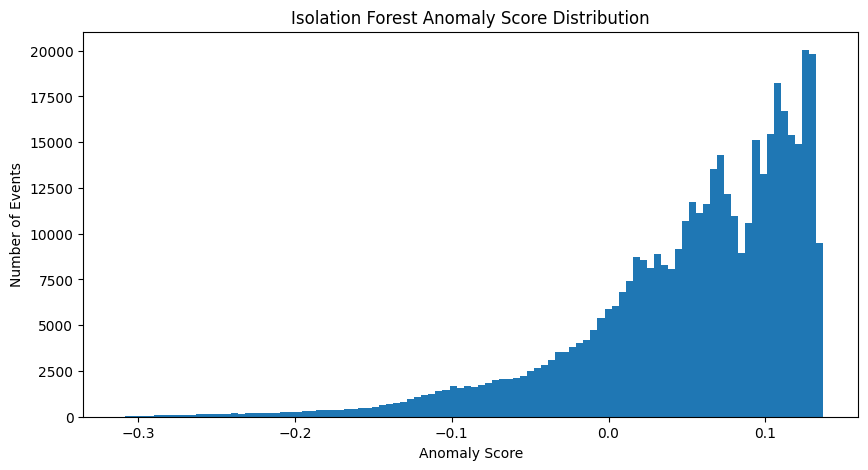

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.hist(
    data["anomaly_score"],
    bins=100
)

plt.xlabel("Anomaly Score")
plt.ylabel("Number of Events")
plt.title("Isolation Forest Anomaly Score Distribution")

plt.show()

#### compare normal vs anomalous events

In [25]:
comparison = (
    data.groupby("is_anomaly")[
        [
            "observation_count",
            "duration_minutes",
            "mean_frp",
            "peak_frp",
            "total_frp"
        ]
    ]
    .mean()
)

comparison.index = ["Normal", "Anomalous"]

comparison

,observation_count,duration_minutes,mean_frp,peak_frp,total_frp
Normal,1.251785,2.622173,4.704100,4.905263,5.983673
Anomalous,3.108013,21.643666,16.476572,23.370274,46.758252


In [26]:
from pathlib import Path
import joblib

PROJECT_ROOT = Path(
    r"C:\Users\DIPANSHU SHUKLA\OneDrive\Desktop\SIH_162_ML"
)

RESULT_DIR = PROJECT_ROOT / "data" / "results"
RESULT_DIR.mkdir(parents=True, exist_ok=True)

RESULT_FILE = RESULT_DIR / "thermal_anomaly_prototype.csv"

data.to_csv(RESULT_FILE, index=False)

print("Saved successfully:")
print(RESULT_FILE)
print("\nShape:", data.shape)

Saved successfully:
C:\Users\DIPANSHU SHUKLA\OneDrive\Desktop\SIH_162_ML\data\results\thermal_anomaly_prototype.csv

Shape: (439251, 25)


#### save the model:

In [27]:
MODEL_DIR = PROJECT_ROOT / "model"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

joblib.dump(
    model,
    MODEL_DIR / "isolation_forest_prototype.joblib"
)

joblib.dump(
    scaler,
    MODEL_DIR / "scaler_prototype.joblib"
)

print("Model and scaler saved successfully.")

Model and scaler saved successfully.
